In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [30]:
# 1 Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

In [31]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [32]:
# 2 Reduce features to 2D for visualization
pca = PCA(n_components=2)
X = pca.fit_transform(X)

In [33]:
X

array([[1160.1425737 , -293.91754364],
       [1269.12244319,   15.63018184],
       [ 995.79388896,   39.15674324],
       ...,
       [ 314.50175618,   47.55352518],
       [1124.85811531,   34.12922497],
       [-771.52762188,  -88.64310636]], shape=(569, 2))

In [34]:
# 3 Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [35]:

# 4 Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
model = SVC(kernel='linear', C=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9649122807017544


In [37]:
# 7 Plot decision boundary
def plot_svm(model, X, y):

    plt.figure(figsize=(8,6))

    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")

    ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy)
    Z = Z.reshape(XX.shape)

    # decision boundary
    ax.contour(XX, YY, Z, levels=[0], colors="black")

    # margin lines
    ax.contour(XX, YY, Z, levels=[-1, 1],
               colors="black", linestyles="dashed")

    # support vectors
    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors="none",
        edgecolors="black"
    )

    plt.title("Linear SVM Decision Boundry")
    plt.show()

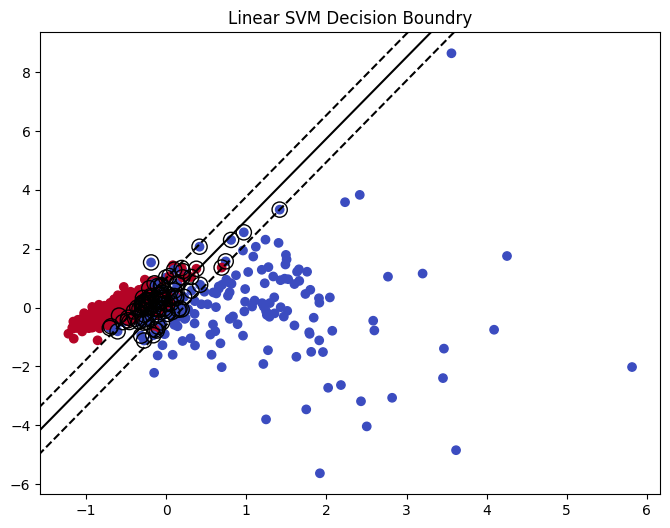

In [38]:
plot_svm(model, X_train, y_train)